In [1]:
import rasterio
from rasterio.merge import merge
import glob

files = sorted(glob.glob("tehri_landslide/data/DEM/*.tif"))
datasets = [rasterio.open(f) for f in files]

mosaic, transform = merge(datasets)

meta = datasets[0].meta.copy()
meta.update({
    "height": mosaic.shape[1],
    "width": mosaic.shape[2],
    "transform": transform
})

with rasterio.open("tehri_landslide/data/DEM/SRTM_mosaic_4326.tif", "w", **meta) as dst:
    dst.write(mosaic)

for ds in datasets:
    ds.close()

print("SRTM tiles mosaicked")


SRTM tiles mosaicked


In [2]:
from rasterio.warp import calculate_default_transform, reproject, Resampling

src_path = "tehri_landslide/data/DEM/SRTM_mosaic_4326.tif"
dst_path = "tehri_landslide/data/DEM/SRTM_mosaic_32644.tif"

with rasterio.open(src_path) as src:
    transform, width, height = calculate_default_transform(
        src.crs, "EPSG:32644",
        src.width, src.height,
        *src.bounds
    )

    meta = src.meta.copy()
    meta.update({
        "crs": "EPSG:32644",
        "transform": transform,
        "width": width,
        "height": height,
        "nodata": -32768  # SRTM default
    })

    with rasterio.open(dst_path, "w", **meta) as dst:
        for i in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, i),
                destination=rasterio.band(dst, i),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs="EPSG:32644",
                resampling=Resampling.bilinear
            )

print("Reprojected to EPSG:32644")


Reprojected to EPSG:32644


In [3]:
import geopandas as gpd
from rasterio.mask import mask
import numpy as np

tehri = gpd.read_file("F:/New folder (2)/tehri_new/tehri.shp")
geoms = tehri.geometry.values

with rasterio.open("tehri_landslide/data/DEM/SRTM_mosaic_32644.tif") as src:
    out_image, out_transform = mask(
        src, geoms, crop=True, nodata=-32768
    )

    meta = src.meta.copy()
    meta.update({
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform,
        "nodata": -32768,
        "dtype": "float32"
    })

    out_image = out_image.astype("float32")

    with rasterio.open("tehri_landslide/data/DEM/DEM_Tehri.tif", "w", **meta) as dst:
        dst.write(out_image)

print("DEM clipped to Tehri")


DEM clipped to Tehri


In [3]:
import rasterio

with rasterio.open("tehri_landslide/data/DEM/DEM_Tehri.tif") as src:
    print("Declared NoData:", src.nodata)
    print("Data type:", src.dtypes)

Declared NoData: -32768.0
Data type: ('float32',)


In [4]:
import numpy as np
import rasterio

with rasterio.open("tehri_landslide/data/DEM/DEM_Tehri.tif") as src:
    arr = src.read(1).astype("float32")
    
    nodata = src.nodata
    print("NoData value:", nodata)

    arr[arr == nodata] = np.nan

    print("Min elevation:", np.nanmin(arr))
    print("Max elevation:", np.nanmax(arr))
    print("Resolution (m):", src.res)

NoData value: -32768.0
Min elevation: 329.0
Max elevation: 6711.0
Resolution (m): (27.116912536875038, 27.116912536875038)


In [5]:
import numpy as np
import rasterio

input_path = "tehri_landslide/data/DEM/DEM_Tehri.tif"
output_path = "tehri_landslide/data/DEM/DEM_Tehri_fixed.tif"

with rasterio.open(input_path) as src:
    arr = src.read(1).astype("float32")
    meta = src.meta.copy()
    
    nodata = src.nodata
    print("Declared NoData:", nodata)
    
    # Replace nodata with NaN
    arr[arr == nodata] = np.nan
    
    print("Min elevation:", np.nanmin(arr))
    print("Max elevation:", np.nanmax(arr))
    print("Resolution (m):", src.res)

    # Update metadata
    meta.update(dtype="float32", nodata=np.nan)

    # Save fixed DEM
    with rasterio.open(output_path, "w", **meta) as dst:
        dst.write(arr, 1)

print("DEM fixed and saved.")

Declared NoData: -32768.0
Min elevation: 329.0
Max elevation: 6711.0
Resolution (m): (27.116912536875038, 27.116912536875038)
DEM fixed and saved.


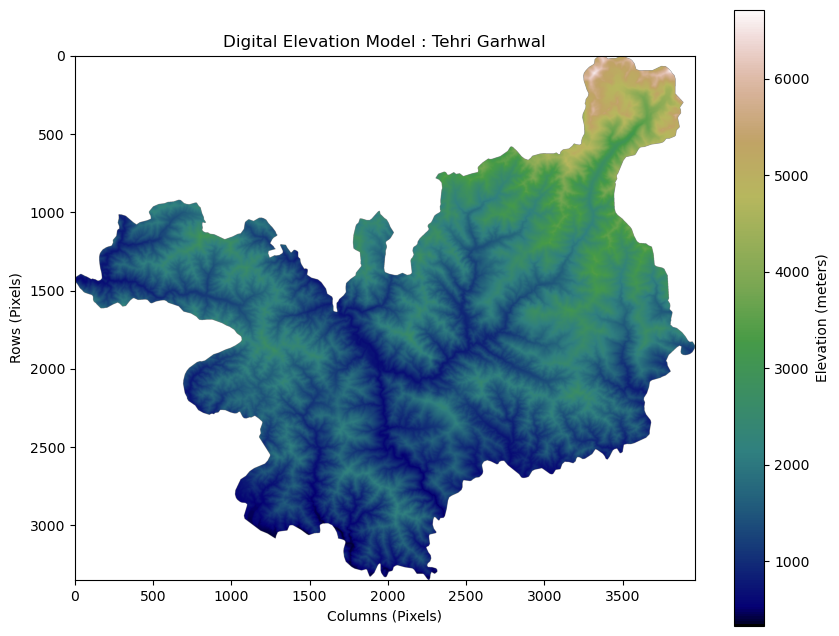

In [6]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import numpy as np

def visualize_dem(file_path):
    # Open the TIFF file
    with rasterio.open(file_path) as src:
        # Read the elevation data (Band 1)
        dem_data = src.read(1)
        
        # Mask out 'No Data' values (often very large negative numbers)
        # This ensures the color scale focuses on actual terrain
        dem_data = np.where(dem_data == src.nodata, np.nan, dem_data)

        # Create the visualization
        plt.figure(figsize=(10, 8))
        
        # Use a 'terrain' or 'viridis' colormap for elevation
        img = plt.imshow(dem_data, cmap='gist_earth')
        
        # Add a colorbar to show elevation scale
        plt.colorbar(img, label='Elevation (meters)')
        
        plt.title(f"Digital Elevation Model : Tehri Garhwal")
        plt.xlabel("Columns (Pixels)")
        plt.ylabel("Rows (Pixels)")
        
        plt.show()

# Usage
visualize_dem('tehri_landslide/data/DEM/DEM_Tehri_fixed.tif')